# Semantic Segmentation of Satellite Images using U-Net Model

### **Introduction**

#### In this notebook, I will implement a U-net Model based on xresnet34 which can segement whether a pixel is building or not. For this project I am using the SpaceNet7 Temporal Dataset. 

### End-to-End Workflow: SpaceNet7 Building Detection

▼  
**1. Data Preparation**  
   ├─ ▼ **Load SpaceNet7 Dataset**  
   │   ├→ 60 scenes × ~24 monthly images (1024×1024px)  
   │   └→ GeoJSON building footprints  
   ├─ ▼ **Preprocess Images**  
   │   ├→ Apply UDM masks (remove clouds/shadows)  
   │   └→ Generate binary masks (0=land, 1=buildings)  
   └─ ▼ **Create Training Subset**  
       ├→ Select 1 image/scene (56 total)  
       └→ Split into 255×255 tiles (16 tiles/image)  

▼  
**2. Handle Class Imbalance**  
   ├─ ▼ **Undersampling**  
   │   └→ Remove tiles with no buildings (~10% discarded)  
   └─ ▼ **Weighted Loss**  
       └→ CrossEntropyLoss([0.25, 0.75] for land/buildings)  

▼  
**3. Data Augmentation**  
   ├→ Random flips/rotations (±180°)  
   ├→ Brightness/contrast/saturation adjustments  
   └→ Normalize with ImageNet stats  

▼  
**4. Model Setup**  
   ├─ ▼ **Architecture**  
   │   └→ U-Net with pretrained xresnet34 encoder  
   ├─ ▼ **Optimization**  
   │   ├→ Adam optimizer  
   │   └→ Slanted LR (3e-5 to 3e-4)  
   └─ ▼ **Metrics**  
       ├→ Dice score (primary)  
       └→ Foreground accuracy (recall)  

▼  
**5. Training**  
   ├→ 40 epochs with `fit_one_cycle`  
   ├→ LR warmup + annealing  
   └→ Best model: Dice=0.57 (epoch 34)  

▼  
**6. Evaluation**  
   ├─ ▼ **Quantitative**  
   │   ├→ Dice: 0.57 (6.5% building pixels)  
   │   └→ FG Accuracy: ~57%  
   └─ ▼ **Qualitative**  
       ├→ Good small-building detection  
       └→ Struggled with dense urban areas  

▼ 


##### Import the Necessary libraries 

In [1]:
from fastai.vision.all import *  #A deep learning library based on PyTorch.
from tqdm import tqdm
from pdb import set_trace
from pprint import pprint

import wandb # A experimemtal Library used to track the deep learning parameters.
from fastai.callback.wandb import *


### **About the Dataset**


#### The dataset contains the satellite images from 60 places for over a span of 2 years with respective geospatial vector files for each image. The main aim of this dataset to track the changes over time (Instance Segementation) but this dataset is used for Semantic Segmentation (classify whether a pixel is a building or not) 

#### The original dataset contains 11,080 images; however, for this project, a subset of 60 scenes was selected, with one representative image per scene used for training.

#### They annotated each and every pixel of an image for this project and it's a time consuming task. So, for each image there is a vector file.

In [2]:
path = Path('/home/azureuser/cloudfiles/code/Users/surabhi/data/train') # I have stored this dataset in Azure DataLake Storage
Path.BASE_PATH = path

#### **Define the Model Parameters**

In [3]:
BATCH_SIZE = 12 
TILES_PER_SCENE = 16
ARCHITECTURE = xresnet34     # Backbone CNN architecture used for feature extraction
EPOCHS = 40
CLASS_WEIGHTS = [0.25,0.75]  # Weights to handle class imbalance: [Land, Building]
LR_MAX = 3e-4                # Maximum Learning rate
ENCODER_FACTOR = 10
CODES = ['Land','Building']

#### Create a dictionary consisting of model parameters

In [4]:
config_dictionary = dict(
    bs=BATCH_SIZE,
    tiles_per_scene=TILES_PER_SCENE,
    architecture = str(ARCHITECTURE),
    epochs = EPOCHS,
    class_weights = CLASS_WEIGHTS,
    lr_max = LR_MAX,
    encoder_factor = ENCODER_FACTOR
)

### **DATA PREPROCESSING**

##### Each place or area is organized into multiple subfolders that include:
##### - Raw images
##### - Tiled image patches
##### - Ground truth masks
##### - Vector labels
##### - Auxiliary data such as binary masks and unusable data masks (UDM)

###### The code below lists the number of folders in the training data. There were 60 folders initially, I had to remove 3 folders due to insufficient data.

In [5]:
scenes = path.ls().sorted()
print(f'Numer of scenes: {len(scenes)}')
print(list(scenes)[:5])

Numer of scenes: 57
[Path('L15-0358E-1220N_1433_3310_13'), Path('L15-0361E-1300N_1446_2989_13'), Path('L15-0368E-1245N_1474_3210_13'), Path('L15-0387E-1276N_1549_3087_13'), Path('L15-0434E-1218N_1736_3318_13')]


In [6]:
sample_scene = (path/'L15-1389E-1284N_5557_3054_13')
print(list(sample_scene.ls()))

[Path('L15-1389E-1284N_5557_3054_13/binary_mask'), Path('L15-1389E-1284N_5557_3054_13/images'), Path('L15-1389E-1284N_5557_3054_13/images_masked'), Path('L15-1389E-1284N_5557_3054_13/img_tiles'), Path('L15-1389E-1284N_5557_3054_13/labels'), Path('L15-1389E-1284N_5557_3054_13/labels_match'), Path('L15-1389E-1284N_5557_3054_13/labels_match_pix'), Path('L15-1389E-1284N_5557_3054_13/mask_tiles')]


##### The code below lists the number of masked images for each place. 

In [7]:
images_masked = (sample_scene/'images_masked').ls().sorted()
labels = (sample_scene/'labels_match').ls().sorted()
print(f'Numer of images in scene: {len(images_masked)}')
pprint(list(images_masked[:5]))

Numer of images in scene: 24
[Path('L15-1389E-1284N_5557_3054_13/images_masked/global_monthly_2018_02_mosaic_L15-1389E-1284N_5557_3054_13.tif'),
 Path('L15-1389E-1284N_5557_3054_13/images_masked/global_monthly_2018_03_mosaic_L15-1389E-1284N_5557_3054_13.tif'),
 Path('L15-1389E-1284N_5557_3054_13/images_masked/global_monthly_2018_04_mosaic_L15-1389E-1284N_5557_3054_13.tif'),
 Path('L15-1389E-1284N_5557_3054_13/images_masked/global_monthly_2018_05_mosaic_L15-1389E-1284N_5557_3054_13.tif'),
 Path('L15-1389E-1284N_5557_3054_13/images_masked/global_monthly_2018_06_mosaic_L15-1389E-1284N_5557_3054_13.tif')]


In [8]:
image, shapes = images_masked[0], labels[0]


Sample Satellite Image

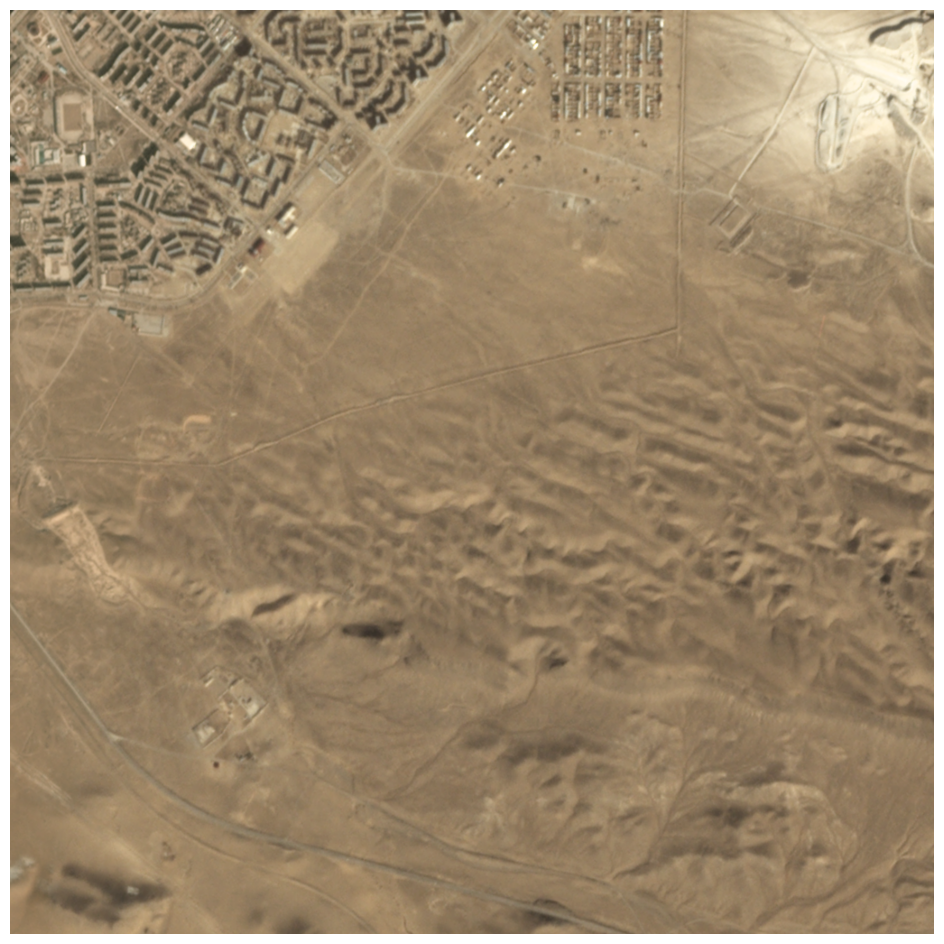

In [21]:
show_image(PILImage.create(image), figsize=(12,12));

#### **Creating Binary Masks**

##### Binary masks convert complex geospatial annotations (e.g., GeoJSON polygons) into a 2D grid of 0s and 1s, where:
##### 
##### 0 = Background (land, water, etc.)
##### 
##### 1 = Foreground (building pixels).
##### 
##### This makes it easier for the model to learn "building vs. not building" without handling intricate polygon coordinates during training.

In [9]:
import rasterio
from rasterio.plot import reshape_as_image
import rasterio.mask 
from rasterio.features import rasterize


import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import mapping, Point, Polygon
from shapely.ops import cascaded_union

##### Create a function to generate Binary Masks from masked images. The masked images were created to remove clouds from the raw images. Using these masked images will reduce the computational power.

In [10]:
def generate_binary_mask(raster_path, shape_path, output_path=None, file_name=None):

    #load raster file
    with rasterio.open(raster_path, "r") as src:
         raster_img = src.read()
         raster_meta = src.meta
    
    #load shapefile
    train_df = gpd.read_file(shape_path)

    #function to generate the binary masks
    def poly_from_utm(polygon, transform):
        poly_pts = []

        poly = cascaded_union(polygon)
        for i in np.array(poly.exterior.coords):

            poly_pts.append(~transform * tuple(i))

        new_poly = Polygon(poly_pts)
        return new_poly
    
    
    poly_shp = []
    im_size = (src.meta['height'], src.meta['width'])
    for num, row in train_df.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            poly = poly_from_utm(row['geometry'], src.meta['transform'])
            poly_shp.append(poly)
        else:
            for p in row['geometry']:
                poly = poly_from_utm(p, src.meta['transform'])
                poly_shp.append(poly)

    #set_trace()
    
    if len(poly_shp) > 0:
      mask = rasterize(shapes=poly_shp,
                      out_shape=im_size)
    else:
      mask = np.zeros(im_size)
    
    # Save or show mask
    mask = mask.astype("uint8")    
    bin_mask_meta = src.meta.copy()
    bin_mask_meta.update({'count': 1})
    if (output_path != None and file_name != None):
      os.chdir(output_path)
      with rasterio.open(file_name, 'w', **bin_mask_meta) as dst:
          dst.write(mask * 255, 1)
    else: 
      return mask

In [11]:
import matplotlib.pyplot as plt

##### Sample binary mask

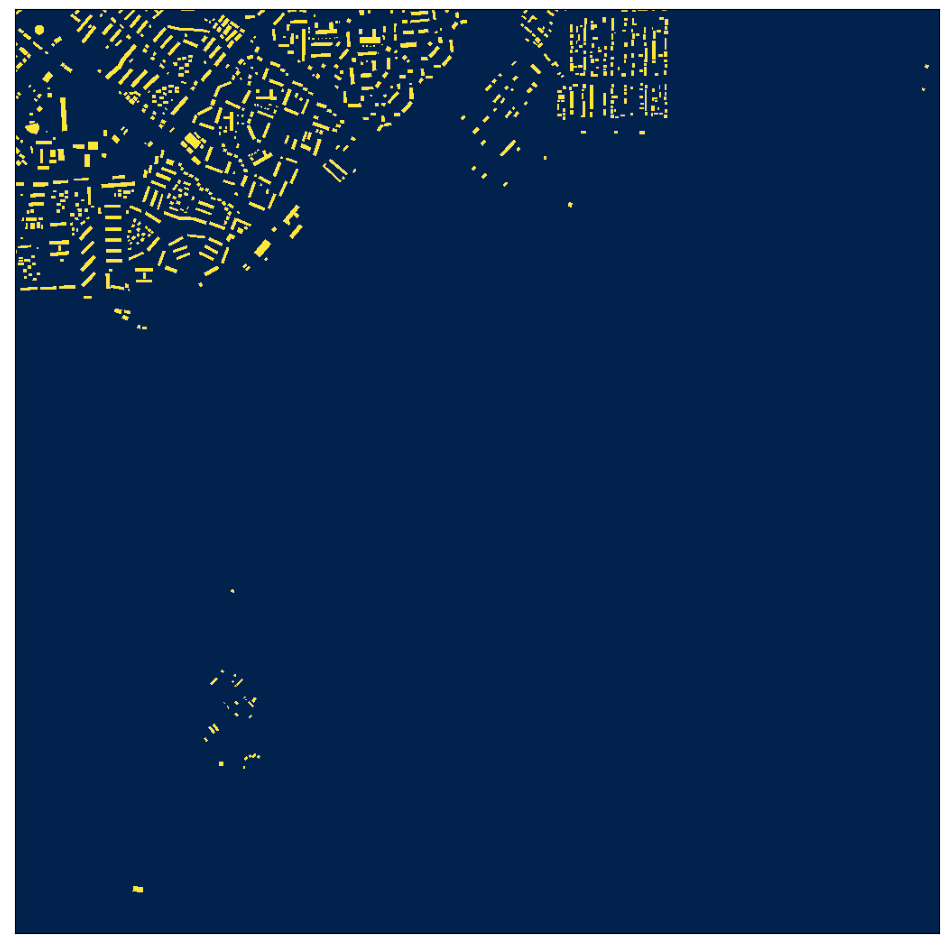

In [20]:
mask = generate_binary_mask(image, shapes)
plt.figure(figsize=(12,12))
plt.tight_layout()
plt.xticks([])
plt.yticks([])
plt.imshow(mask,cmap='cividis');

#### Loop through all the masked images and create binary masks and save them in their respective folder

In [13]:
for scene in tqdm(path.ls().sorted()):
     masked_img_dir = scene / 'images_masked'
     label_dir = scene / 'labels_match'
     output_dir = scene / 'binary_mask'

       
     if not output_dir.exists():
        os.makedirs(output_dir)

    for img in masked_img_dir.ls():
            # Skip hidden or non-raster files
        if img.suffix.lower() not in ['.tif', '.tiff']:
            continue

        shapes = label_dir / (img.name[:-4] + '_Buildings.geojson')
        output_mask_path = output_dir / img.name

        if not output_mask_path.exists():
            generate_binary_mask(img, shapes, output_dir, img.name)


##### After the above code is executed, it will create binary masks for each masked image and save in their respective folder.

### **Creating subset of dataset**

##### There are 24 images for each scene. That is 60 places multiplied by 24 images. All of 24 images for each place are quite similar.The vegetation changes with the seasons and some scenes show building activity, but overall the similarities are greater than the differences.

##### Therefore I decided to ignore most images. I originally planned to keep every fifth image of every scene, so for example January, June, November, April, and September. This way we could make use of the variability of the different seasons. But it turned out that just selecting one image per scene yielded similar results with a fraction of the training time.

##### The function below selects one masked image from each place

In [12]:
#collapse
def get_masked_images(path:Path, n=1)->list:
  "Returns the first `n` pictures from every scene"
  files = []
  for folder in path.ls():
    files.extend(get_image_files(path=folder, folders='images_masked')[:n])
  return files

##### A total of 56 masked images are selected from 56 folders

In [15]:
masked_images = get_masked_images(path, 1)
len(masked_images)

56

#### **Cutting images in tiles**

##### Since the images are large (1024x1024), we cut them into 16 smaller tiles (255x255) and save them to disk. Most structures are small in relation to the whole scene, so this should not hurt training too much. Smaller tiles allow for larger batch sizes and/or deeper models to fit in CPU RAM.

##### Most images have 1024x1024 pixels. Some images however have only 1023 pixels in one dimension, therefore I chose 255 instead of 256 as the tile size. This throws away some pixels in most images, but maintains an equal tile size for all images.
##### 
##### To do: Ideally, we would create overlapping tiles to avoid some buildings being cut in half and never seen in their full shape by the model.

In [13]:
#collapse
def cut_tiles(tile_size:int):
  "Cuts the large images and masks into equal tiles and saves them to disk"
  masked_images = get_masked_images(path, 5)
  for fn in tqdm(masked_images):
    scene = fn.parent.parent

    # Create directories
    if not os.path.exists(scene/'img_tiles'):
      os.makedirs(scene/'img_tiles')
    if not os.path.exists(scene/'mask_tiles'):
      os.makedirs(scene/'mask_tiles')

    # Create mask for current image
    img = np.array(PILImage.create(fn))
    msk_fn = str(fn).replace('images_masked', 'binary_mask')
    msk = np.array(PILMask.create(msk_fn))
    x, y, _ = img.shape

    # Cut tiles and save them
    for i in range(x//tile_size):
      for j in range(y//tile_size):
        img_tile = img[i*tile_size:(i+1)*tile_size,j*tile_size:(j+1)*tile_size]
        msk_tile = msk[i*tile_size:(i+1)*tile_size,j*tile_size:(j+1)*tile_size]
        Image.fromarray(img_tile).save(f'{scene}/img_tiles/{fn.name[:-4]}_{i}_{j}.png')
        Image.fromarray(msk_tile).save(f'{scene}/mask_tiles/{fn.name[:-4]}_{i}_{j}.png')

Call the above function to cut the tiles

In [ ]:
TILE_SIZE = 255
cut_tiles(TILE_SIZE)

#### **Little helper functions**

In [14]:
def get_image_tiles(path:Path, n_tiles=TILES_PER_SCENE) -> L:
  "Returns a list of the first `n` image tile filenames in `path`"
  files = L()
  for folder in path.ls():
    files.extend(get_image_files(path=folder, folders='img_tiles')[:n_tiles])
  return files

In [15]:
def get_y_fn(fn:Path) -> str:
  "Returns filename of the associated mask tile for a given image tile"
  return str(fn).replace('img_tiles', 'mask_tiles')

In [16]:
def get_y(fn:Path) -> PILMask:
  "Returns a PILMask object of 0s and 1s for a given tile"
  fn = get_y_fn(fn)
  msk = np.array(PILMask.create(fn))
  msk[msk==255] = 1
  return PILMask.create(msk)

##### **Visualization of the tiles and their respective binary mask**

In [17]:
#collapse
def show_tiles(n):
  all_tiles = get_image_tiles(path)
  subset = random.sample(all_tiles, n)
  fig, ax = plt.subplots(n//2, 4, figsize=(14,14))
  for i in range(n):
    y = i//2
    x = 2*i%4
    PILImage.create(subset[i]).show(ctx=ax[y, x])
    get_y(subset[i]).show(ctx=ax[y, x+1], cmap='cividis')
  fig.tight_layout()
  plt.show()

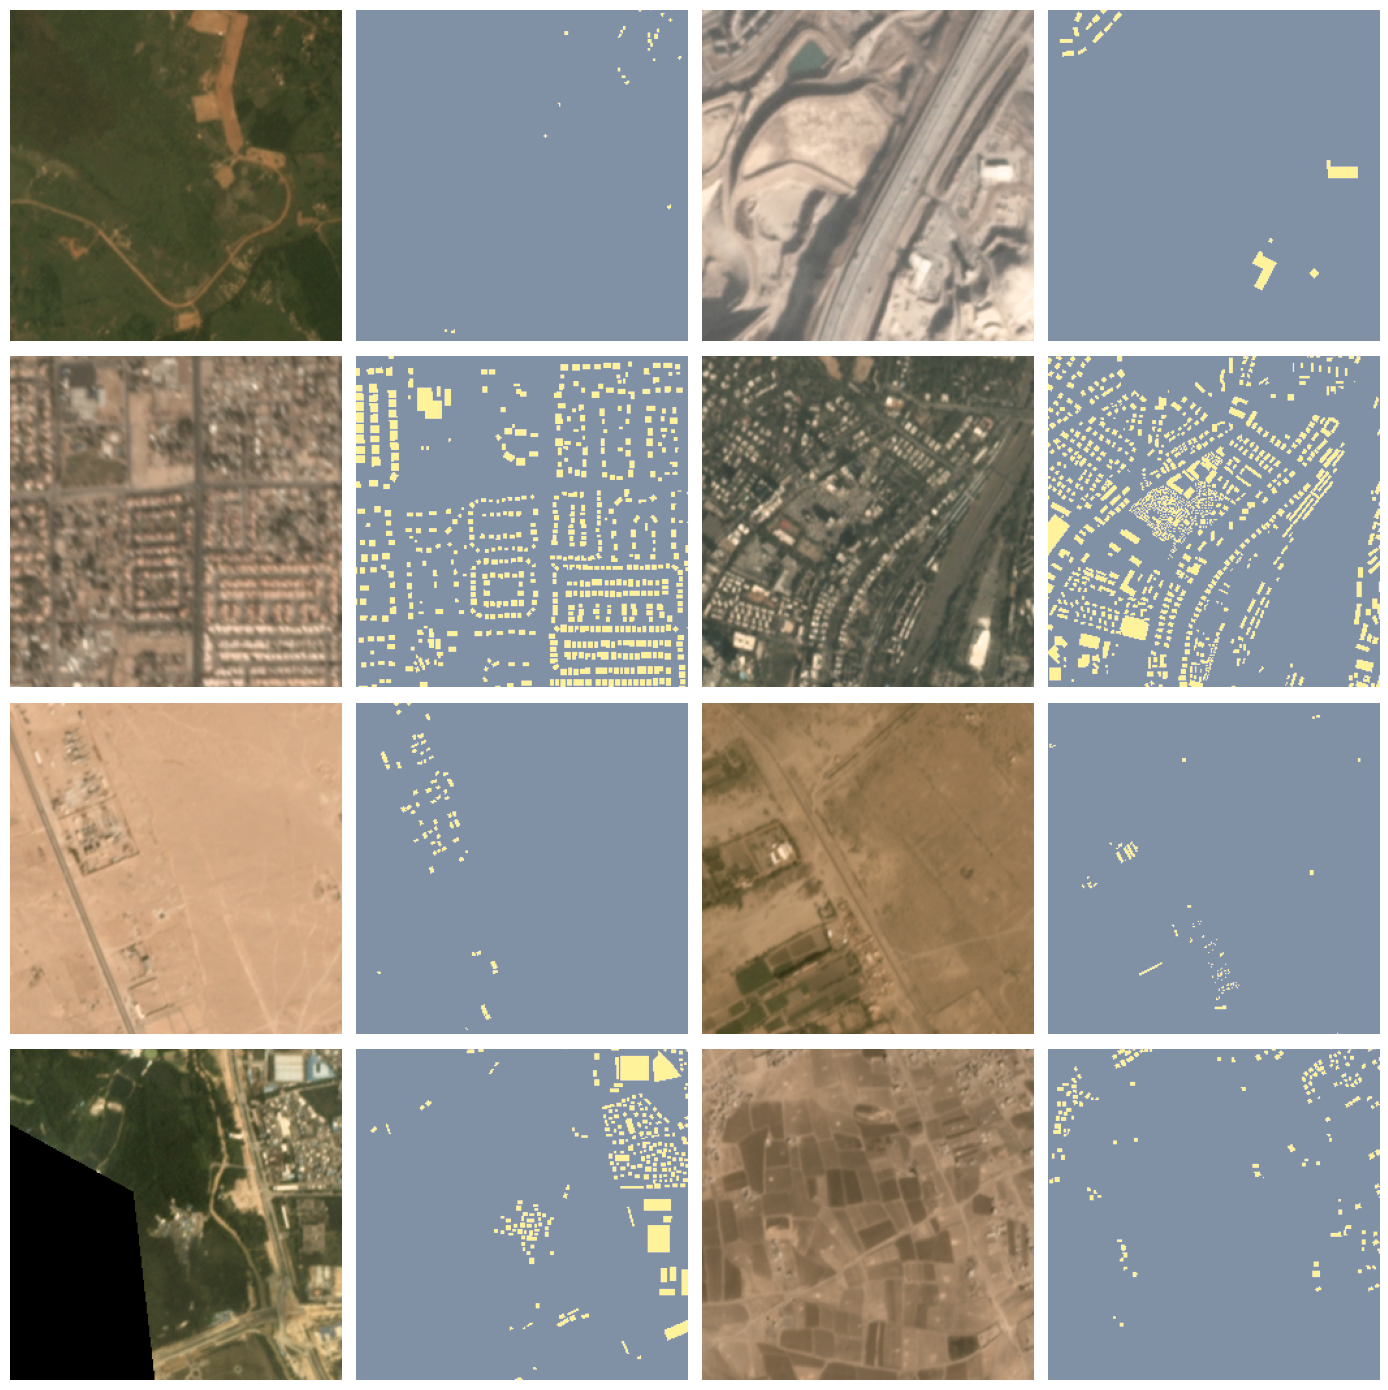

In [37]:
show_tiles(8)

#### _**Challenges of the dataset**_
##### As we can see in the visualizations, the dataset provides some challenges:
1. ##### The buildings are often extremely small, just a few pixels, and very close to each other
2. ##### On the other hand, there are large structures that cover a much greater area than small buildings
3. ##### Some buildings are hard to recognize, even for the human eye
4. ##### The density of buildings varies greatly. There are tiles with no buildings at all, other tiles show urban scenes with hundreds of buildings
5. ##### The images are very diverse, with great differences in topography, vegetation and urbanization
6. ##### Some tiles are covered partially or completely with UDM masks

In [18]:
#collapse
tiles = DataBlock(
      blocks = (ImageBlock(),MaskBlock(codes=CODES)),
      get_items = get_image_tiles,
      get_y = get_y
    )              
dls = tiles.dataloaders(path, bs=BATCH_SIZE)
dls.vocab = CODES                 

In [19]:
targs = torch.zeros((0,255,255))
for _, masks in dls[0]:
  targs = torch.cat((targs, masks.cpu()), dim=0)
targs.shape

torch.Size([708, 255, 255])

#### **Validation Strategy**

##### To allow the evaluation of the performance of our model, we set aside 15% of the dataset as validation set.
##### 
##### We must be thoughtful about how we create this validation set. Using random images would be too easy, as we have several images per scene that differ only slightly. Our validation set would not be thoroughly separated from the training set.
##### 
##### Instead, I chose to randomly select 9 scenes that are used as validation data. The model will never see any images from these scenes during training.
##### 



In [20]:
VALID_SCENES = ['L15-0571E-1075N_2287_3888_13',
 'L15-1615E-1205N_6460_3370_13',
 'L15-1210E-1025N_4840_4088_13',
 'L15-1185E-0935N_4742_4450_13',
 'L15-1481E-1119N_5927_3715_13',
 'L15-0632E-0892N_2528_4620_13',
 'L15-1438E-1134N_5753_3655_13',
 'L15-0924E-1108N_3699_3757_13',
 'L15-0457E-1135N_1831_3648_13']

In [21]:
def valid_split(item):
  scene = item.parent.parent.name
  return scene in VALID_SCENES

#### **Undersampling**

##### To help mitigating the imbalanced classes, we remove all tiles that contain no buildings at all from the training set. This reduces the amount of samples by ~10%, thereby accelerating the training while helping the model perform better.

In [22]:

def has_buildings(fn:Path) -> bool:
  """Returns whether the mask of a given image tile
  contains at least one pixel of a building"""
  fn = get_y_fn(fn)
  msk = tensor(PILMask.create(fn))
  count = torch.count_nonzero(msk)
  return count>0.

In [23]:

def get_undersampled_tiles(path:Path) -> L:
  """Returns a list of image tile filenames in `path`.
  For tiles in the training set, empty tiles are ignored.
  All tiles in the validation set are included."""

  files = get_image_tiles(path)
  train_idxs, valid_idxs = FuncSplitter(valid_split)(files)
  train_files = L(filter(has_buildings, files[train_idxs]))
  valid_files = files[valid_idxs]

  return train_files + valid_files

##### **Creating Dataloaders**

##### The following transformations seem reasonable for satellite images. We flip the tiles vertically and horizontally, rotate them, change brightness, contrast and saturation by a small amount. We normalize them according to ImageNet stats, so that we can use a pretrained model later.

In [24]:
tfms = [Dihedral(0.5),              # Horizontal and vertical flip
        Rotate(max_deg=180, p=0.9), # Rotation in any direction possible
        Brightness(0.2, p=0.75),
        Contrast(0.2),
        Saturation(0.2),
        Normalize.from_stats(*imagenet_stats)]

##### To create the datasets, we use the convenient DataBlock API of fastai. We only load 16 tiles per scene, so only 1 image per region.

In [25]:
tiles = DataBlock(
      blocks = (ImageBlock(),MaskBlock(codes=CODES)), # Independent variable is Image, dependent variable is Mask
      get_items = get_undersampled_tiles,             # Collect undersampled tiles
      get_y = get_y,                                  # Get dependent variable: mask
      splitter = FuncSplitter(valid_split),           # Split into training and validation set
      batch_tfms = tfms                               # Transforms on GPU: augmentation, normalization
    )                              

In [26]:
dls = tiles.dataloaders(path, bs=BATCH_SIZE)
dls.vocab = CODES

In [27]:
len(dls.train_ds), len(dls.valid_ds)

(678, 144)

In [28]:
inputs, targets = dls.one_batch()

In [29]:
inputs.shape, targets.shape

(torch.Size([12, 3, 255, 255]), torch.Size([12, 255, 255]))

In [30]:
weights = Tensor(CLASS_WEIGHTS)  # Remove .cuda()
loss_func = CrossEntropyLossFlat(axis=1, weight=weights)

### **Train and test the model**

##### **Defining the Model**

##### The task at hand is an image segmentation problem. In the original competition, it is required to assign individual labels to each building to keep track of it over time (instance segmentation). Here, I chose to do semantic segmentation instead, so just classifying for every pixel if it belongs to a building or not.
##### 
##### The fastai library allows the remarkably simple creation of a U-Net, a standard architecture for image segmentation problems. The module DynamicUNet - provided with an encoder architecture - automatically constructs a decoder and cross connections. This makes it easy to build a U-Net out of different (and pretrained) architectures. I chose this approach to have more time to experiment instead of writing code from scratch. I considered following aspects:
##### 
##### **Encoder**: I picked a xResNet34 model that has been pretrained on ImageNet. A 34-layer encoder seems like a good compromise between accuracy and memory/compute requirements.
##### **Loss function**: The choice of the loss function is important for segmentation problems. I'll use a weighted pixel-wise cross-entropy loss. The weights are important for the imbalanced dataset.
##### **Optimizer**: I use the default optimizer, Adam.
##### **Metrics**:
##### As the classes are very imbalanced, a simple accuracy metric would not be helpful. In a picture with 3% buildings, the model could predict "no building" on every pixel and still get 97% accuracy.
##### Instead, I focus on the Dice metric, it is often used for segmentation tasks. It is equivalent to the F1 score and measures the ratio of  2TP2TP+FP+FN 
##### Additionally, I added foreground_acc of fastai, it measures the percentage of foreground pixels correctly classified, the Recall. Foreground in this case is the building class.


##### With some experimentation, the class weights 0.25 for the background and 0.75 for the building class seem to work fine.

In [31]:
learn = unet_learner(dls,                                 # DataLoaders containing masked tiles (input) and binary mask tiles (Output) 
                     ARCHITECTURE,                        # xResNet34
                     loss_func = loss_func,               # Weighted cross entropy loss
                     opt_func = Adam,                     # Adam optimizer
                     metrics = [Dice(), foreground_acc],  # Custom metrics
                     self_attention = False,
                     cbs = [SaveModelCallback(
                              monitor='dice',
                              comp=np.greater,
                              fname='best-model'
                            )]
                     )

##### Summary of the model:

In [32]:
#collapse_output
learn.summary()

DynamicUnet (Input shape: 12 x 3 x 255 x 255)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 32 x 128 x 128 
Conv2d                                    864        False     
BatchNorm2d                               64         True      
ReLU                                                           
Conv2d                                    9216       False     
BatchNorm2d                               64         True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 128 x 128 
Conv2d                                    18432      False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 64 x 64   
MaxPool2d                         

##### This is the full UNet model:

In [33]:
#collapse_output
learn.model

DynamicUnet(
  (layers): ModuleList(
    (0): Sequential(
      (0): ConvLayer(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ConvLayer(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ConvLayer(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): ResBlock(
          (convpath): Sequential(
            (0): ConvLayer(
              (0): Conv2d(64, 64, kernel_size=(

#### **Training**

SuggestedLRs(valley=3.630780702224001e-05)

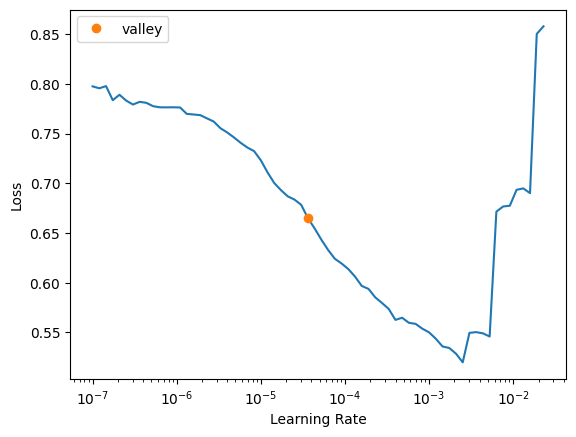

In [34]:
learn.lr_find()

##### Somewhere around 1e-4 seems reasonable, where the loss decreases steadily.

In [35]:
lr_max = LR_MAX 

##### W&B (wandb) is a machine learning experiment tracking tool that helps you log, visualize, and collaborate on ML projects. Think of it like a "GitHub for ML models" with real-time dashboards.

In [36]:
#hide
wandb.init(project="adm", entity="surabhimanoj20082001-michigan-technological-university", config=config_dictionary)  


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: surabhimanoj20082001 (surabhimanoj20082001-michigan-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [37]:
#collapse-output
learn.unfreeze()
learn.fit_one_cycle(
    EPOCHS,
    lr_max=slice(lr_max/ENCODER_FACTOR, lr_max),
    cbs=[WandbCallback()]
)

epoch,train_loss,valid_loss,dice,foreground_acc,time
0,0.437824,0.439451,0.238566,0.139039,15:39
1,0.374679,0.374594,0.377486,0.259867,15:26
2,0.351985,0.352095,0.462896,0.395387,15:28
3,0.335153,0.394495,0.399460,0.254463,15:29
4,0.330030,0.324129,0.520512,0.512828,15:29
5,0.328252,0.316100,0.532993,0.508433,15:28
6,0.319807,0.347883,0.442406,0.314430,15:29
7,0.314003,0.317531,0.543973,0.516638,15:33
8,0.298551,0.330644,0.516214,0.428155,15:34
9,0.289391,0.335249,0.507725,0.408765,15:29


Better model found at epoch 0 with dice value: 0.23856568667858727.
Better model found at epoch 1 with dice value: 0.3774856343888008.
Better model found at epoch 2 with dice value: 0.46289595194079797.
Better model found at epoch 4 with dice value: 0.5205123288344765.
Better model found at epoch 5 with dice value: 0.5329927922814699.
Better model found at epoch 7 with dice value: 0.5439731864648911.
Better model found at epoch 11 with dice value: 0.5512193782269581.
Better model found at epoch 12 with dice value: 0.558501164638084.
Better model found at epoch 14 with dice value: 0.5682027807034644.
Better model found at epoch 18 with dice value: 0.5728662616552834.
Better model found at epoch 26 with dice value: 0.5763866390011271.
Better model found at epoch 28 with dice value: 0.5770529326147942.
Better model found at epoch 29 with dice value: 0.5796508382423184.
Better model found at epoch 38 with dice value: 0.5807211270029358.


##### During training, our model achieved its best validation performance at epoch 38 with a Dice score of 0.5807 (58.07% overlap between predicted and actual building pixels). 

In [45]:
learn.load('best-model');

#### **Visualizing the Results**

##### Let's get all predictions on the validation set and have a look at them.

In [39]:
probs,targets,preds,losses = learn.get_preds(dl=dls.valid,
                                             with_loss=True,
                                             with_decoded=True,
                                             act=None)

In [47]:

def show_single_pred(index: int):
    fig, ax = plt.subplots(1, 4, figsize=(20, 5))

    dls.valid_ds[index][0].show(ctx=ax[0])
    ax[0].set_title("Input")

    show_at(dls.valid_ds, index, cmap='Blues', ctx=ax[1])
    ax[1].set_title("Target")

    ax[2].imshow(preds[index], cmap='Blues')
    ax[2].set_title("Prediction Mask")

    ax[3].imshow(probs[index][1], cmap='viridis')
    ax[3].set_title("Building class probability")


##### **Plot the samples with the lowest losses**

Tile #TensorBase(4), loss: TensorBase(0.3607)
Tile #TensorBase(110), loss: TensorBase(0.3230)
Tile #TensorBase(101), loss: TensorBase(0.3127)


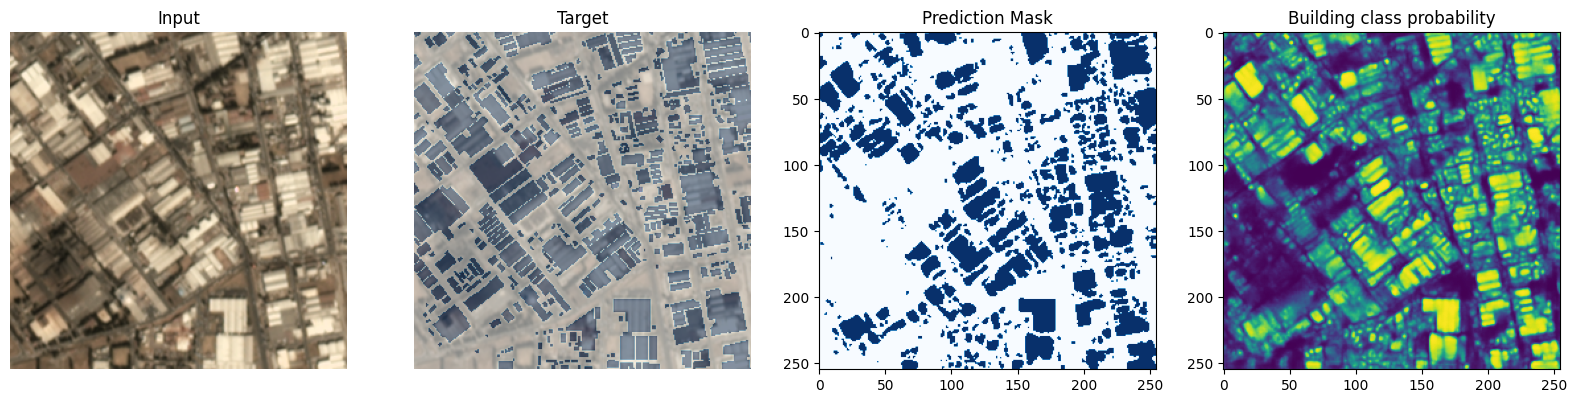

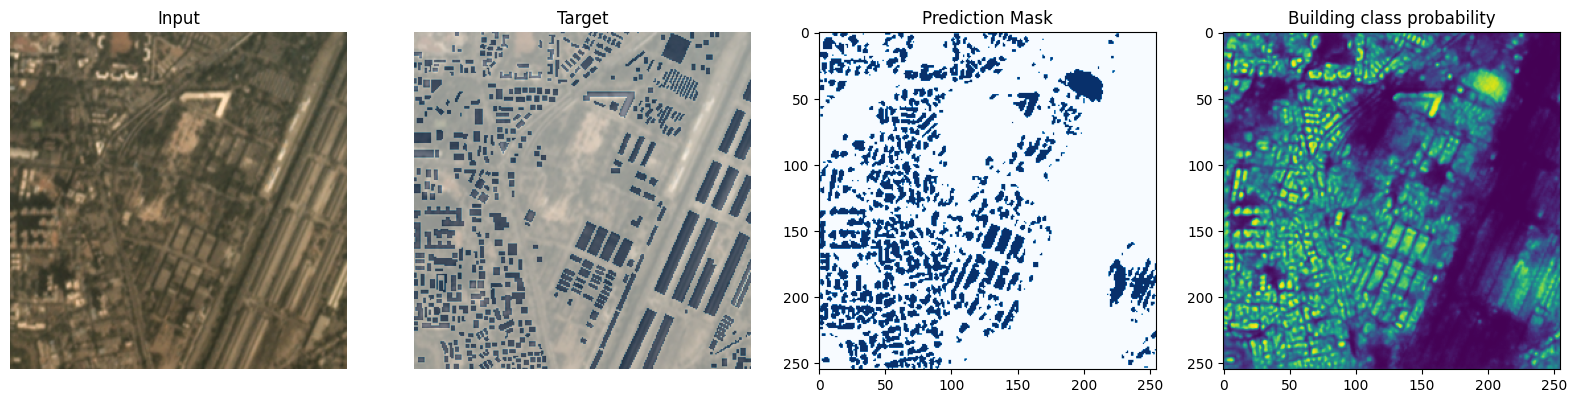

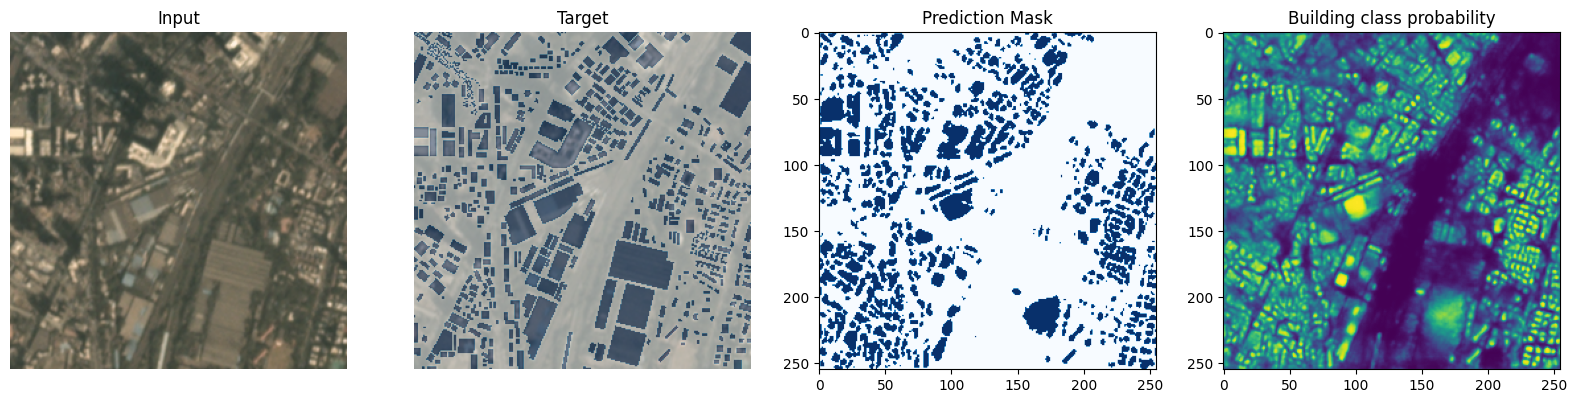

In [48]:

for idx in loss_sorted[:3]:
  print(f'Tile #{idx}, loss: {losses[idx]}')
  show_single_pred(idx)

## **SpaceNet7 Model Summary**

### **Predictions**
- **Task**: Binary building segmentation (0=land, 1=buildings)
- **Best Dice**: `0.5807` (epoch 38)
- **Foreground Acc**: `57%` (building recall)
- **Output**: Probability masks (thresholded at 0.5)

### **Key Parameters**
| Parameter          | Value               | Role                          |
|--------------------|---------------------|-------------------------------|
| **Architecture**   | U-Net (xresnet34)   | Pretrained encoder + decoder  |
| **Batch Size**     | 12                  | CPU memory optimization       |
| **LR Range**       | 3e-5 to 3e-4        | Slanted 1-cycle policy        |
| **Loss Weights**   | [0.25, 0.75]        | Land vs. building priority    |
| **Epochs**         | 40                  | Early stop at best validation |


*"58% building overlap—solid baseline for satellite segmentation!"* 🛰️